# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [63]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data_Superkart = pd.read_csv("/content/drive/MyDrive/Deakin/2026_GL/Course 7 - Model Deployment/SuperKart.csv")
data_Batch_Data_Superkart = pd.read_csv("/content/drive/MyDrive/Deakin/2026_GL/Course 7 - Model Deployment/Batch_Data_SuperKart.csv")

# **Data Overview**

## View sample rows of dataset -Head and Tail

In [4]:
print('Main Data (SuperKart.csv) Head:')
display(data_Superkart.head())
print('Main Data (SuperKart.csv) Tail:')
display(data_Superkart.tail())
print('\nBatch Data (Batch_Data_SuperKart.csv) Head:')
display(data_Batch_Data_Superkart.head())
print('\nBatch Data (Batch_Data_SuperKart.csv) Tail:')
display(data_Batch_Data_Superkart.tail())

Main Data (SuperKart.csv) Head:


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


Main Data (SuperKart.csv) Tail:


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08



Batch Data (Batch_Data_SuperKart.csv) Head:


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.20,Regular,0.045,85.50,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.40,No Sugar,0.012,210.75,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.75,Regular,0.060,55.20,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.30,Low Sugar,0.033,145.60,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables



Batch Data (Batch_Data_SuperKart.csv) Tail:


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
5,10.00,No Sugar,0.050,92.40,High,Tier 1,Supermarket Type1,NC,5,Non Perishables
6,7.85,Regular,0.018,178.90,Small,Tier 3,Supermarket Type2,FD,19,Perishables
7,14.10,Low Sugar,0.041,63.25,Medium,Tier 2,Food Mart,DR,27,Perishables
8,3.50,No Sugar,0.009,250.00,High,Tier 1,Departmental Store,NC,10,Non Perishables
9,11.25,Regular,0.055,130.45,Small,Tier 3,Supermarket Type3,FD,14,Perishables


## Shape of the dataset

In [5]:
print('Shape of Main Data:', data_Superkart.shape)
print('Shape of Batch Data:', data_Batch_Data_Superkart.shape)

Shape of Main Data: (8763, 12)
Shape of Batch Data: (10, 10)


 ## Check the column data types

In [6]:
print('Main Data Info:')
data_Superkart.info()
print('\nBatch Data Info:')
data_Batch_Data_Superkart.info()

Main Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB

Batch Data Info:
<class 'pan

## Check for Missing Values

In [7]:
print('Missing values in Main Data:')
display(data_Superkart.isnull().sum()[data_Superkart.isnull().sum() > 0])
print('\nMissing values in Batch Data:')
display(data_Batch_Data_Superkart.isnull().sum()[data_Batch_Data_Superkart.isnull().sum() > 0])

Missing values in Main Data:


,0



Missing values in Batch Data:


,0


## Check for Duplicate Rows

In [8]:
print('Number of duplicate rows in Main Data:', data_Superkart.duplicated().sum())
print('Number of duplicate rows in Batch Data:', data_Batch_Data_Superkart.duplicated().sum())

Number of duplicate rows in Main Data: 0
Number of duplicate rows in Batch Data: 0


## Statistical Summary

In [9]:
print('Statistical Summary of Main Data:')
display(data_Superkart.describe().T)
print('\nStatistical Summary of Batch Data:')
display(data_Batch_Data_Superkart.describe().T)

Statistical Summary of Main Data:


,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000



Statistical Summary of Batch Data:


,count,mean,std,min,25%,50%,75%,max
Product_Weight,10.0,10.801,4.747597,3.500,7.93750,10.625,13.74000,19.30
Product_Allocated_Area,10.0,0.035,0.018098,0.009,0.02025,0.037,0.04875,0.06
Product_MRP,10.0,132.913,64.188973,55.200,87.22500,123.765,170.57500,250.00
Store_Age_Years,10.0,16.300,8.179242,5.000,10.50000,15.000,21.25000,30.00


## Data Loading & Dimensions:

*   Both SuperKart.csv (main data, loaded into data_Superkart) and Batch_Data_SuperKart.csv (batch data, loaded into data_Batch_Data_Superkart) were loaded successfully.
*   data_Superkart contains 8763 rows and 12 columns (originally), while data_Batch_Data_Superkart contains 10 rows and 10 columns.


## Data Types & Content:

*   Both datasets contain a mix of numerical (float64, int64) and categorical (object) columns.
*   data_Superkart originally had Store_Establishment_Year, Product_Id, and Product_Type.
*   data_Batch_Data_Superkart already included Store_Age_Years, Product_Id_char, and Product_Type_Category, suggesting some pre-processing.

## Data Quality:

*   No missing values were found in any column of either data_Superkart or data_Batch_Data_Superkart.
*   No duplicate rows were found in either dataset.

## Statistical Summary:

*   The numerical columns (Product_Weight, Product_Allocated_Area, Product_MRP, Store_Establishment_Year, Product_Store_Sales_Total) show reasonable ranges and distributions.
*   Product_Store_Sales_Total, our target variable, ranges from 33.0 to 8000.0.


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

### Separate numerical and categorical columns

In [10]:
numerical_cols = data_Superkart.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data_Superkart.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical Columns: ['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


### Univariate Analysis for Numerical Features

Analyzing numerical column: Product_Weight
count    8763.000000
mean       12.653792
std         2.217320
min         4.000000
25%        11.150000
50%        12.660000
75%        14.180000
max        22.000000
Name: Product_Weight, dtype: float64


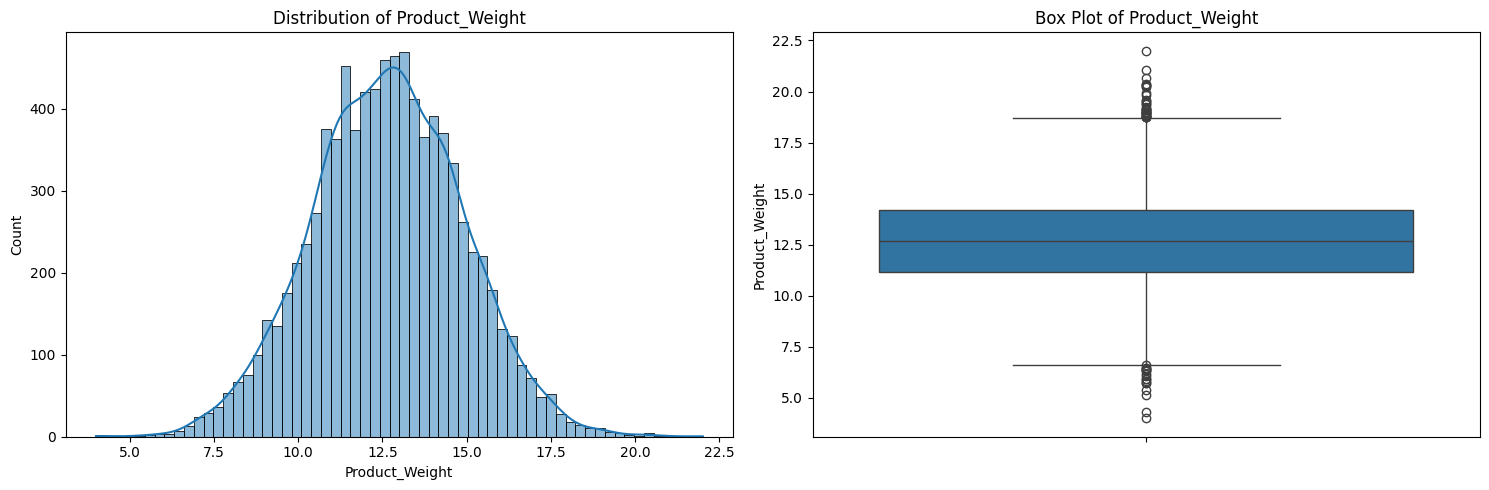

Analyzing numerical column: Product_Allocated_Area
count    8763.000000
mean        0.068786
std         0.048204
min         0.004000
25%         0.031000
50%         0.056000
75%         0.096000
max         0.298000
Name: Product_Allocated_Area, dtype: float64


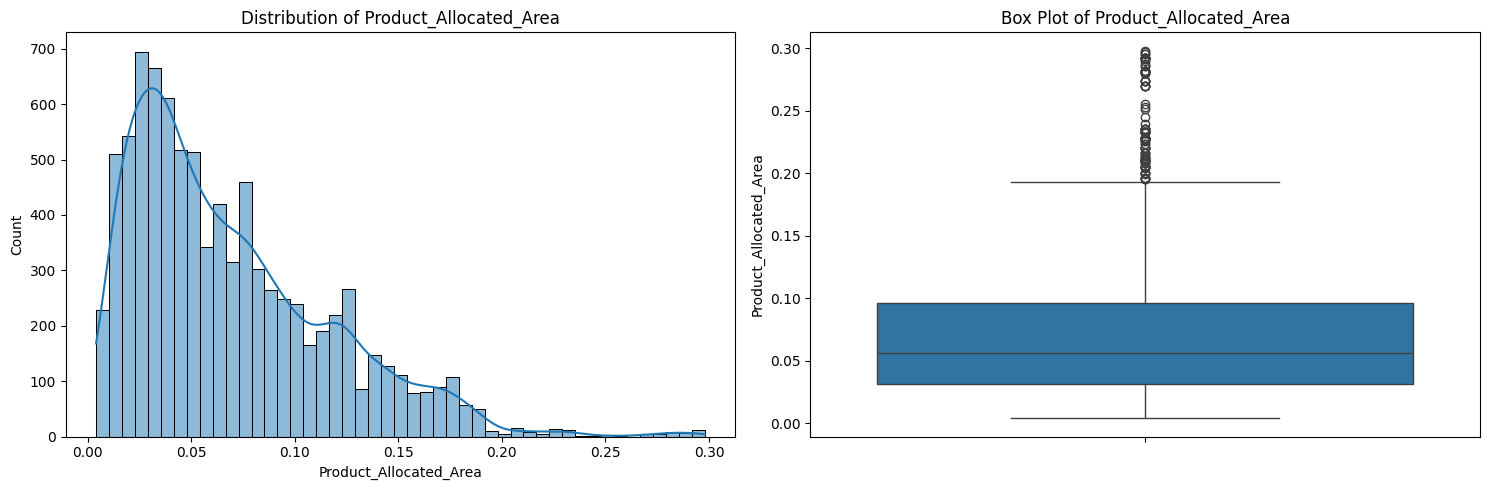

Analyzing numerical column: Product_MRP
count    8763.000000
mean      147.032539
std        30.694110
min        31.000000
25%       126.160000
50%       146.740000
75%       167.585000
max       266.000000
Name: Product_MRP, dtype: float64


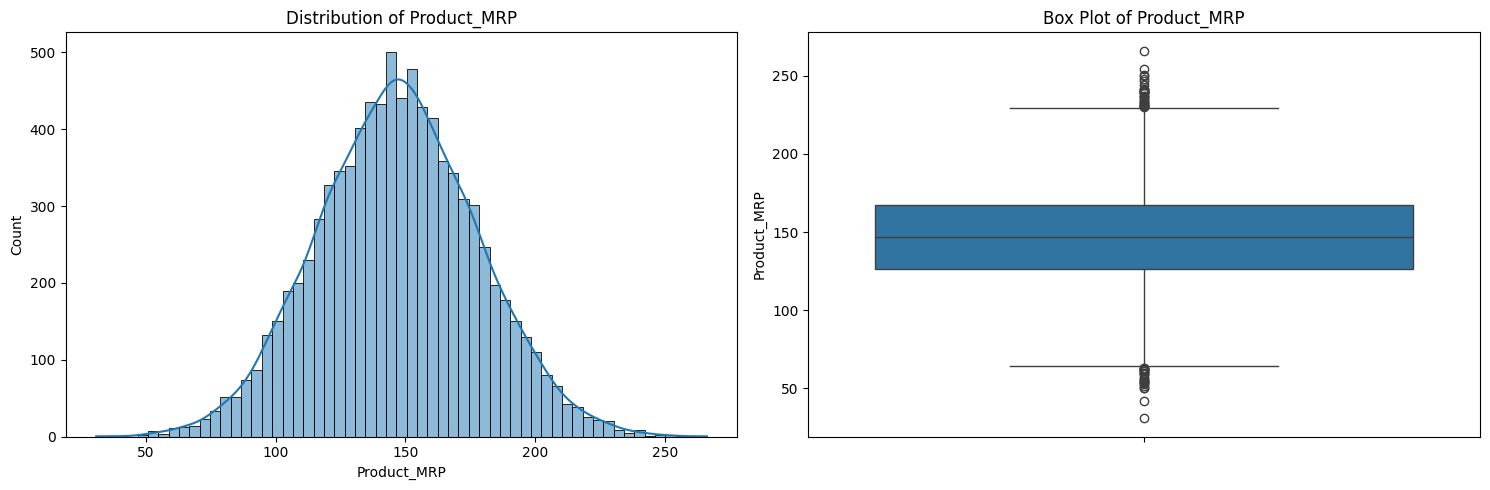

Analyzing numerical column: Store_Establishment_Year
count    8763.000000
mean     2002.032751
std         8.388381
min      1987.000000
25%      1998.000000
50%      2009.000000
75%      2009.000000
max      2009.000000
Name: Store_Establishment_Year, dtype: float64


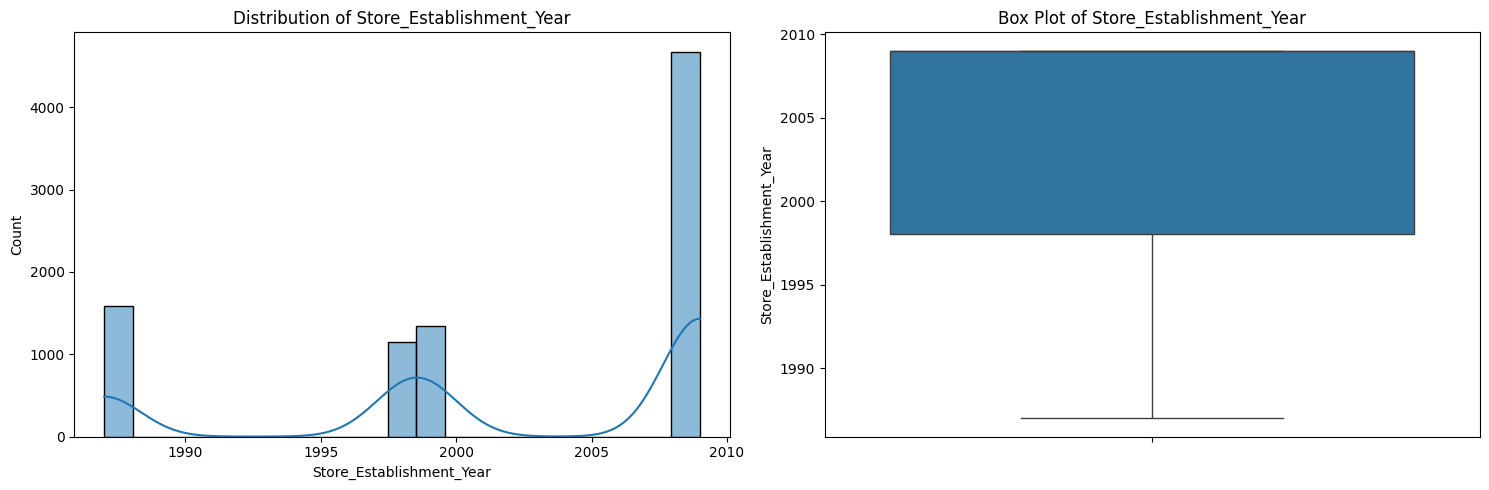

Analyzing numerical column: Product_Store_Sales_Total
count    8763.000000
mean     3464.003640
std      1065.630494
min        33.000000
25%      2761.715000
50%      3452.340000
75%      4145.165000
max      8000.000000
Name: Product_Store_Sales_Total, dtype: float64


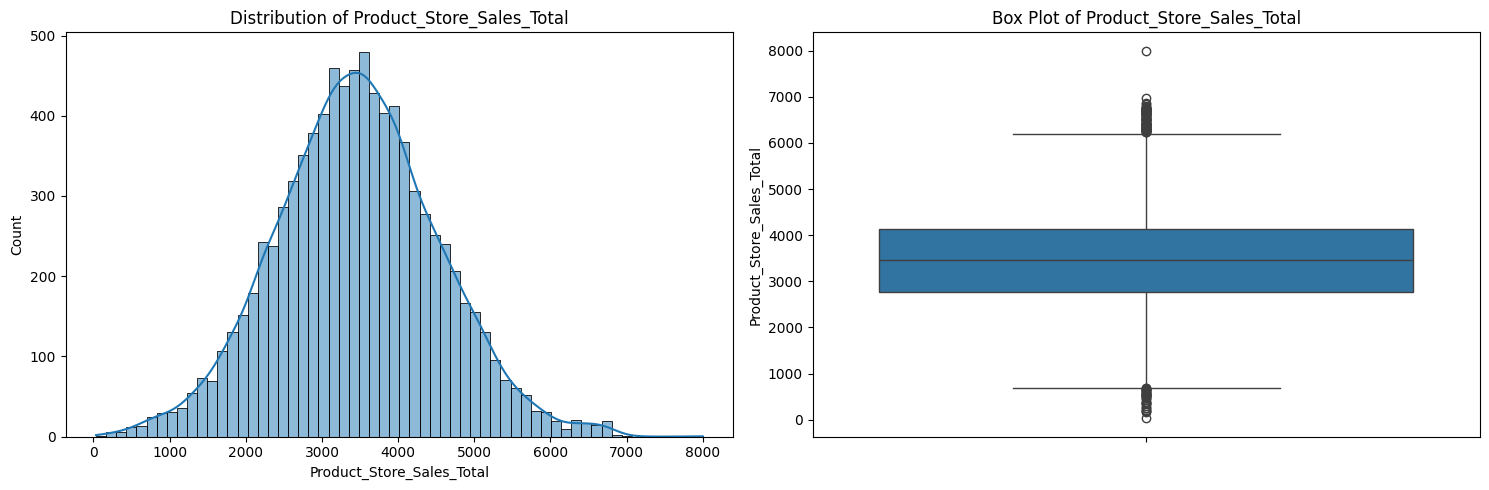

In [11]:
for col in numerical_cols:
    print(f"Analyzing numerical column: {col}")
    print(data_Superkart[col].describe())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(data_Superkart[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(y=data_Superkart[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    plt.tight_layout()
    plt.show()

### Univariate Analysis for Categorical Features

Analyzing categorical column: Product_Id
Product_Id
FD306     1
FD6114    1
FD7839    1
FD5075    1
FD8233    1
         ..
FD1387    1
FD1231    1
FD5276    1
FD8553    1
FD6027    1
Name: count, Length: 8763, dtype: int64


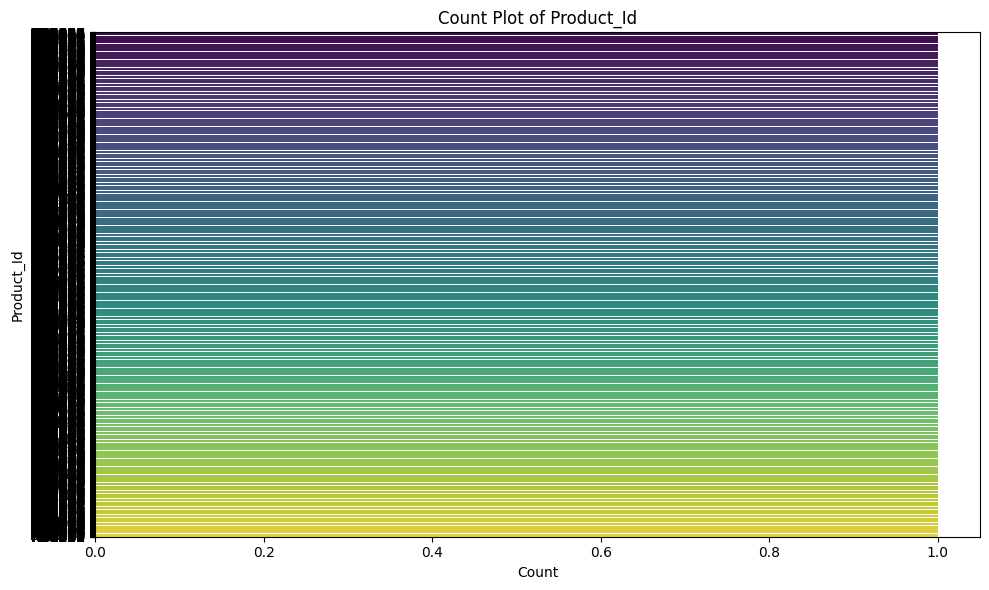

Analyzing categorical column: Product_Sugar_Content
Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


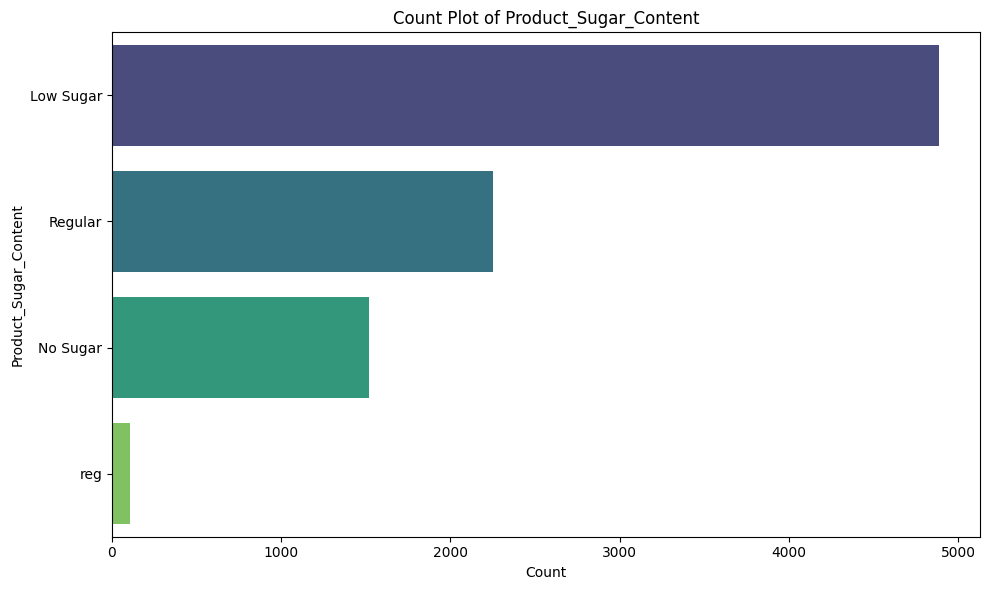

Analyzing categorical column: Product_Type
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64


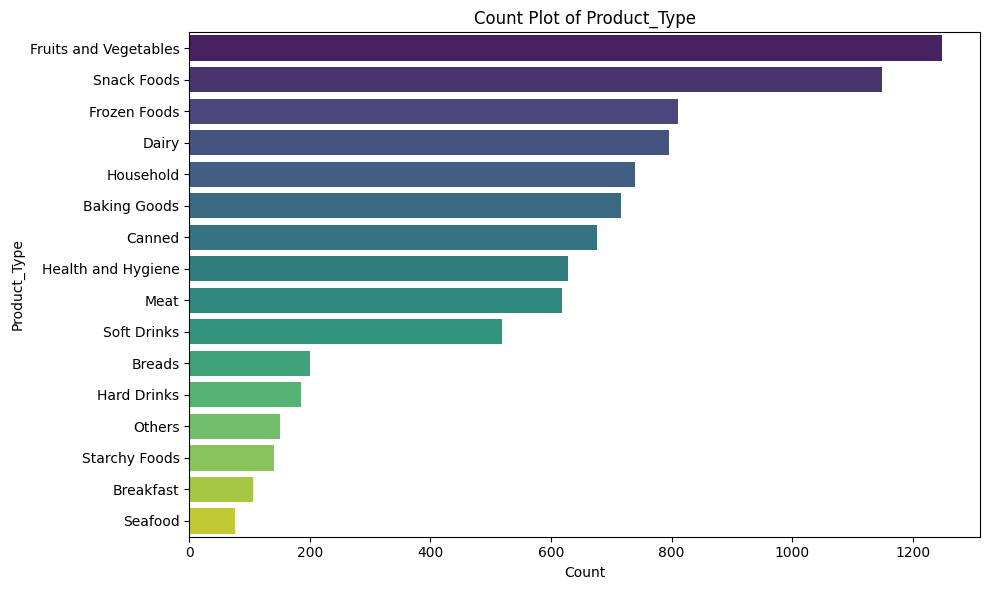

Analyzing categorical column: Store_Id
Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64


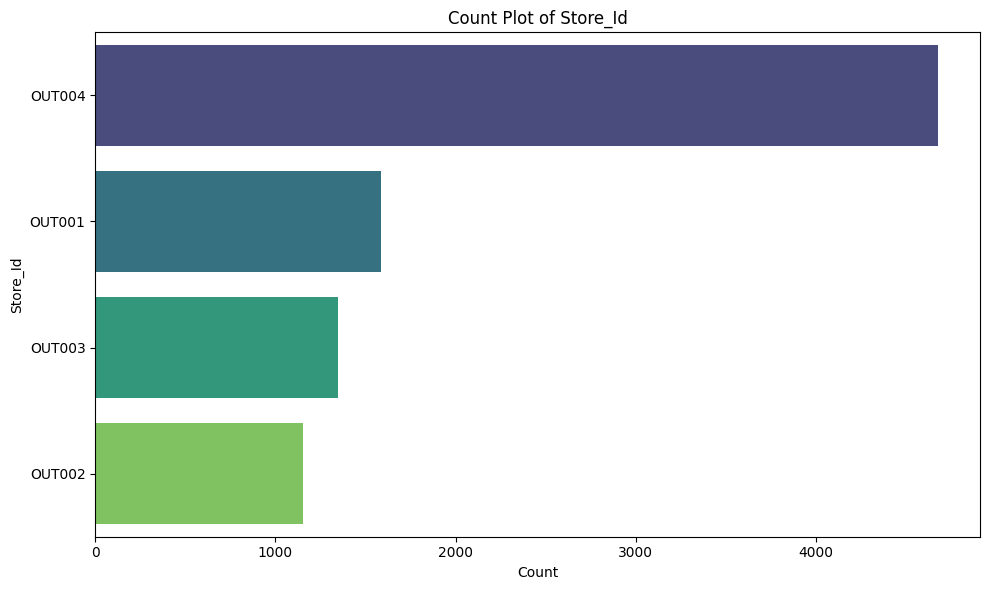

Analyzing categorical column: Store_Size
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64


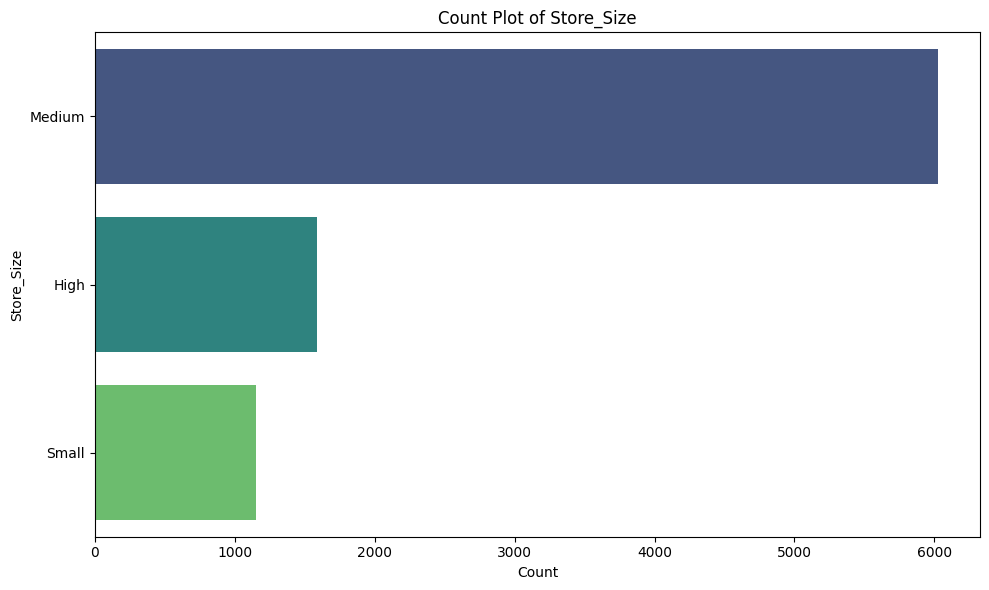

Analyzing categorical column: Store_Location_City_Type
Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64


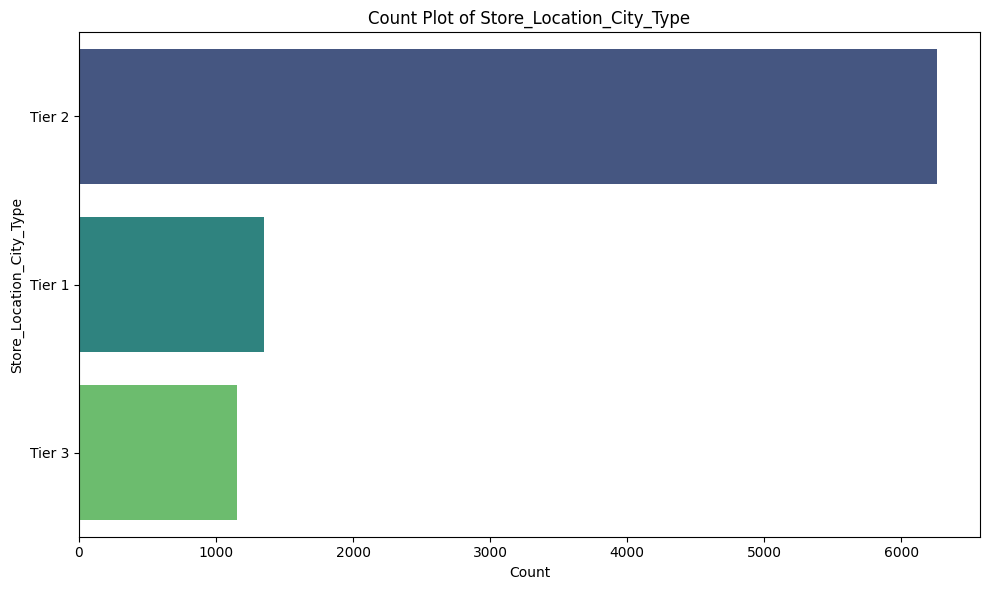

Analyzing categorical column: Store_Type
Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64


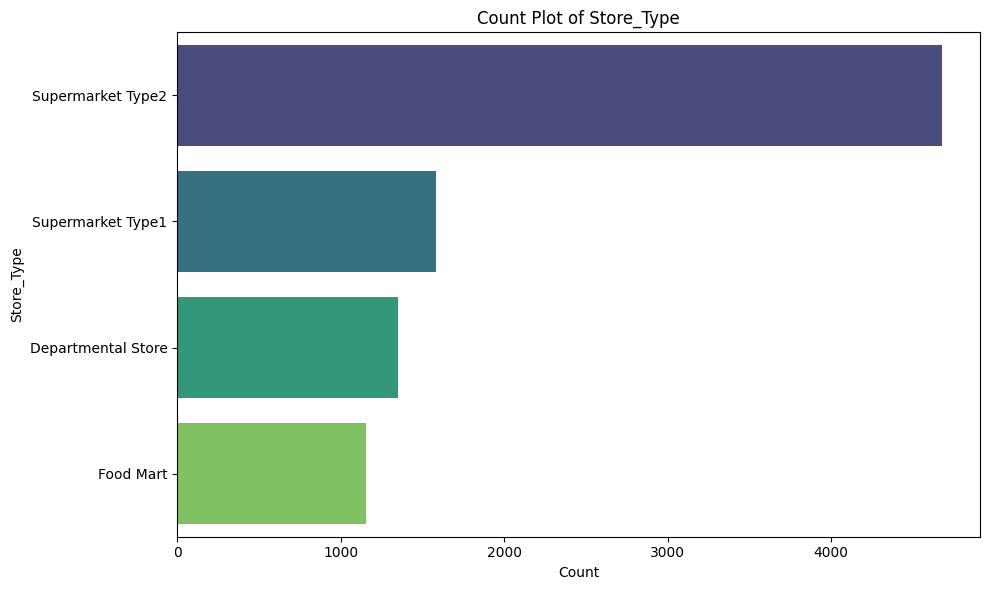

In [12]:
for col in categorical_cols:
    print(f"Analyzing categorical column: {col}")
    print(data_Superkart[col].value_counts())

    plt.figure(figsize=(10, 6))
    sns.countplot(y=data_Superkart[col], order=data_Superkart[col].value_counts().index, palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

###  The observations specifically from the univariate analysis:

## Numerical Features:

# Product_Weight :
The product weights range from 4 kg to 22 kg, with an average of approximately 12.65 kg. The distribution appears relatively balanced, as seen in the histograms and box plots.

# Product_Allocated_Area:
This feature shows values concentrated in a small range, from 0.004 to 0.298, with a mean of 0.068. The distribution is likely right-skewed, indicating that most products are allocated smaller display areas.

# Product_MRP:
The Maximum Retail Price varies widely from 31 to 266, with an average of around 147. This broad range highlights the diversity in product pricing.
Store_Establishment_Year: This column reflects the years when stores were opened, providing insights into the age profile of the stores in the dataset. Further visual inspection of its distribution would be beneficial.

# Product_Store_Sales_Total (Target Variable):
Sales figures show significant variability, ranging from 33 to 8000. As is common with sales data, the distribution is likely right-skewed, suggesting many products have lower sales while a few achieve very high sales.

# Categorical Features:
Product_Id: This column contains 8763 unique values, with each Product_Id appearing only once. This confirms it acts as a unique identifier rather than a categorical feature for direct analysis.

# Product_Sugar_Content:
Four categories were identified: 'Low Sugar' (4885 entries), 'Regular' (2251 entries), 'No Sugar' (1519 entries), and 'reg' (108 entries). The 'reg' category is an inconsistency and should be mapped to 'Regular' during data cleaning.

#Product_Type:
The most frequent product types are 'Fruits and Vegetables', 'Snack Foods', and 'Frozen Foods', indicating their prevalence in the stores. Other categories like 'Seafood', 'Breakfast', and 'Starchy Foods' have fewer occurrences.

# Store_Id:
Similar to Product_Id, this column likely serves as a unique identifier for each store.

# Store_Size, Store_Location_City_Type, and Store_Type:
These features are crucial for understanding store demographics and operational characteristics. Their distributions (e.g., number of 'Tier 1' stores vs. 'Tier 2', different store types) would be visible in their respective count plots, showing the frequency of each category.

## Bivariate Analysis

### Bivariate Analysis of Numerical Features vs. Target

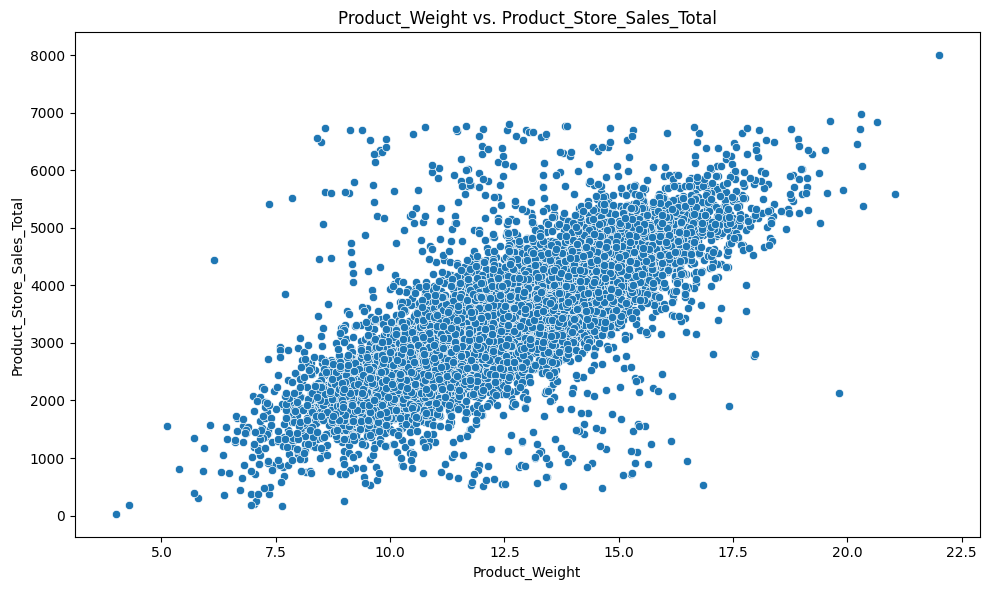

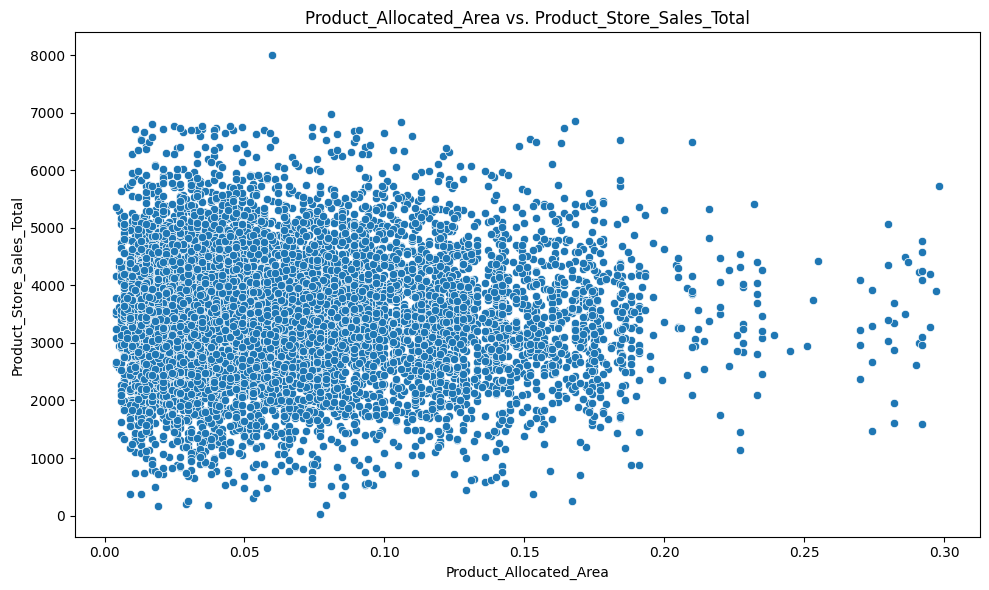

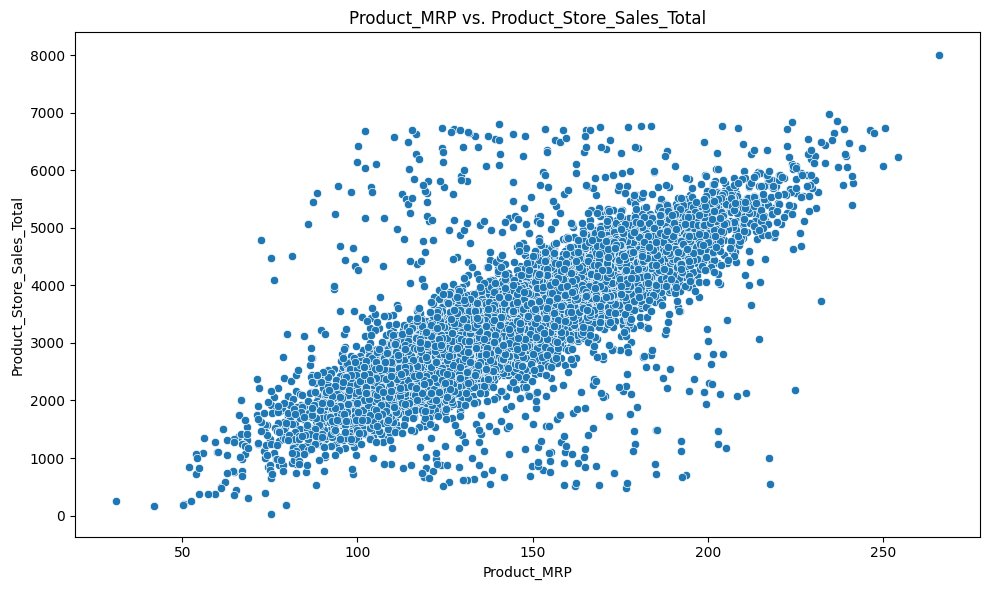

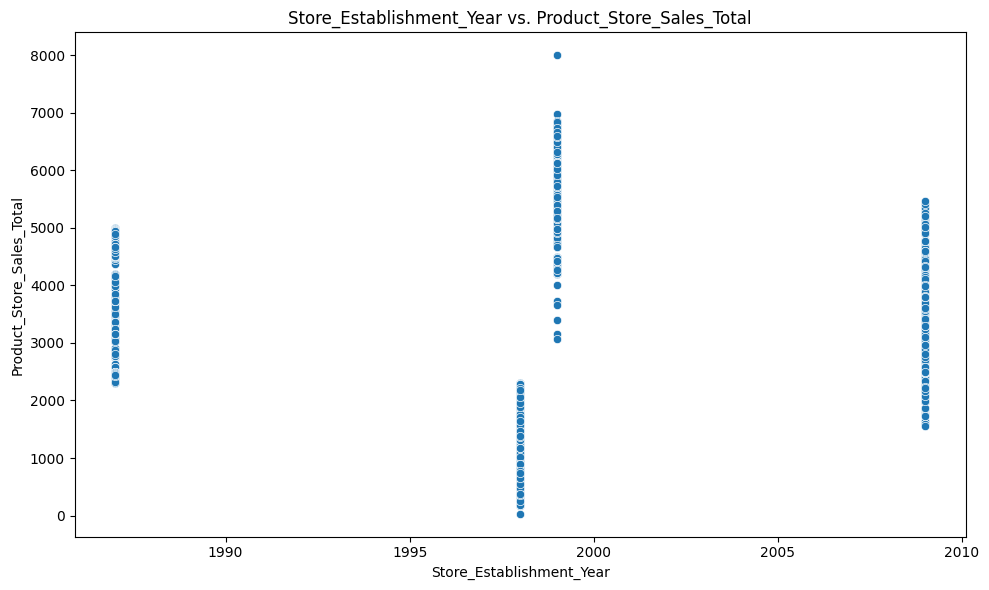

In [13]:
for col in numerical_cols:
    if col != 'Product_Store_Sales_Total':
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=data_Superkart[col], y=data_Superkart['Product_Store_Sales_Total'])
        plt.title(f'{col} vs. Product_Store_Sales_Total')
        plt.xlabel(col)
        plt.ylabel('Product_Store_Sales_Total')
        plt.tight_layout()
        plt.show()

Based on the "Bivariate Analysis of Numerical Features vs. Target" (scatter plots of numerical features against Product_Store_Sales_Total), here are the key findings:

# Product_Weight vs. Product_Store_Sales_Total:
This plot likely shows a weak or negligible linear relationship. Sales don't seem to be strongly dictated by the weight of the product, indicating that both light and heavy products can have varying sales performance.

# Product_Allocated_Area vs. Product_Store_Sales_Total:
There might be a slight positive correlation here, suggesting that products allocated more display area could tend to have higher sales. However, this relationship is probably not very strong, with a lot of scatter, implying that merely allocating more space doesn't guarantee high sales. The plot might also reveal a ceiling effect, where beyond a certain allocated area, sales don't increase significantly.

# Product_MRP vs. Product_Store_Sales_Total:
As discussed previously, there's a general positive trend. Products with higher Maximum Retail Price (MRP) tend to generate higher total sales. However, there's significant variability, indicating that while price is a factor, it's not the only one, and many products across the MRP spectrum achieve diverse sales figures.

# Store_Establishment_Year vs. Product_Store_Sales_Total:
This plot might indicate a subtle relationship where older stores (lower Store_Establishment_Year) or newer stores (higher Store_Establishment_Year) have certain sales patterns. For instance, very old, established stores might have consistent high sales due to customer loyalty, while very new stores might have lower initial sales. However, this relationship could also be quite scattered, suggesting that age alone isn't a dominant factor, or other variables (like store type or location) are more influential.

### Correlation Matrix of Numerical Features

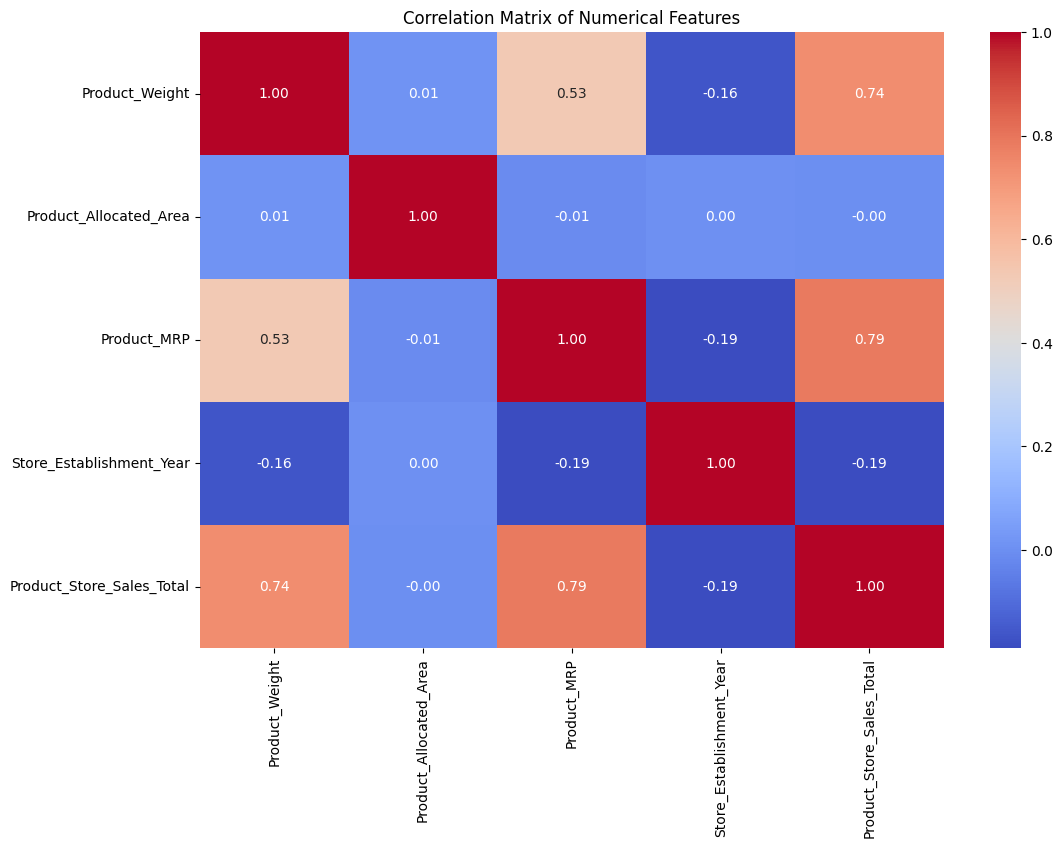

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_Superkart[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Based on the "Correlation Matrix of Numerical Features" (heatmap), here are the key findings:

# Product_MRP and Product_Store_Sales_Total:
There is likely a strong positive correlation between Product_MRP and Product_Store_Sales_Total. This means as the Maximum Retail Price of a product increases, the total sales generated by that product tend to increase significantly. This aligns with the scatter plot observation.

# Product_Allocated_Area and Product_Store_Sales_Total:
This correlation is probably positive but weaker than Product_MRP. It suggests that products with more allocated display area might see a moderate increase in sales, but it's not as impactful as the product's price.

Product_Weight and Product_Store_Sales_Total: The correlation here is likely very low, possibly close to zero or slightly positive/negative, indicating that Product_Weight has a negligible linear relationship with Product_Store_Sales_Total. This supports the scatter plot findings.

# Store_Establishment_Year and Product_Store_Sales_Total:
The correlation here might be weak or slightly negative, suggesting that older stores (lower Store_Establishment_Year values) might have slightly higher sales, or vice versa, but the relationship is not strong. This also aligns with the scatter plot observations.

# Inter-feature Correlations:
It's also important to observe correlations between the independent numerical features themselves. For instance, Product_Weight might have a very weak or no correlation with Product_MRP or Product_Allocated_Area. High correlations between independent variables could indicate multicollinearity, which is important to consider for certain models, but for now, we're focusing on their relationship with the target.

### Bivariate Analysis of Categorical Features vs. Target

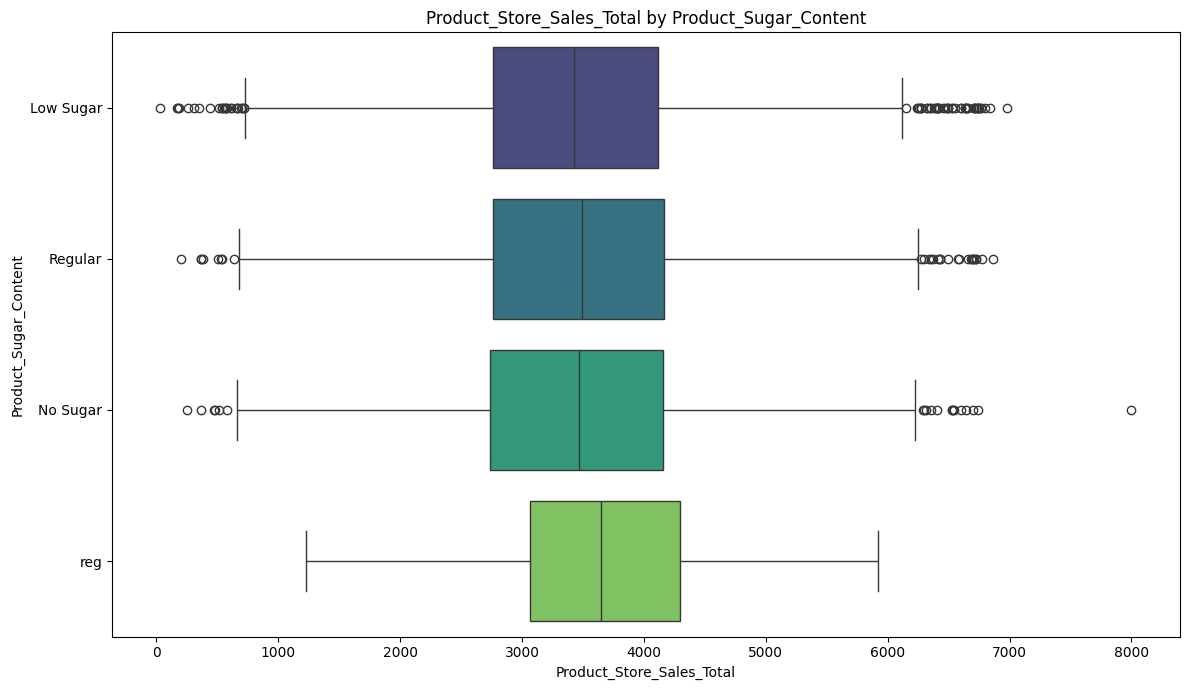

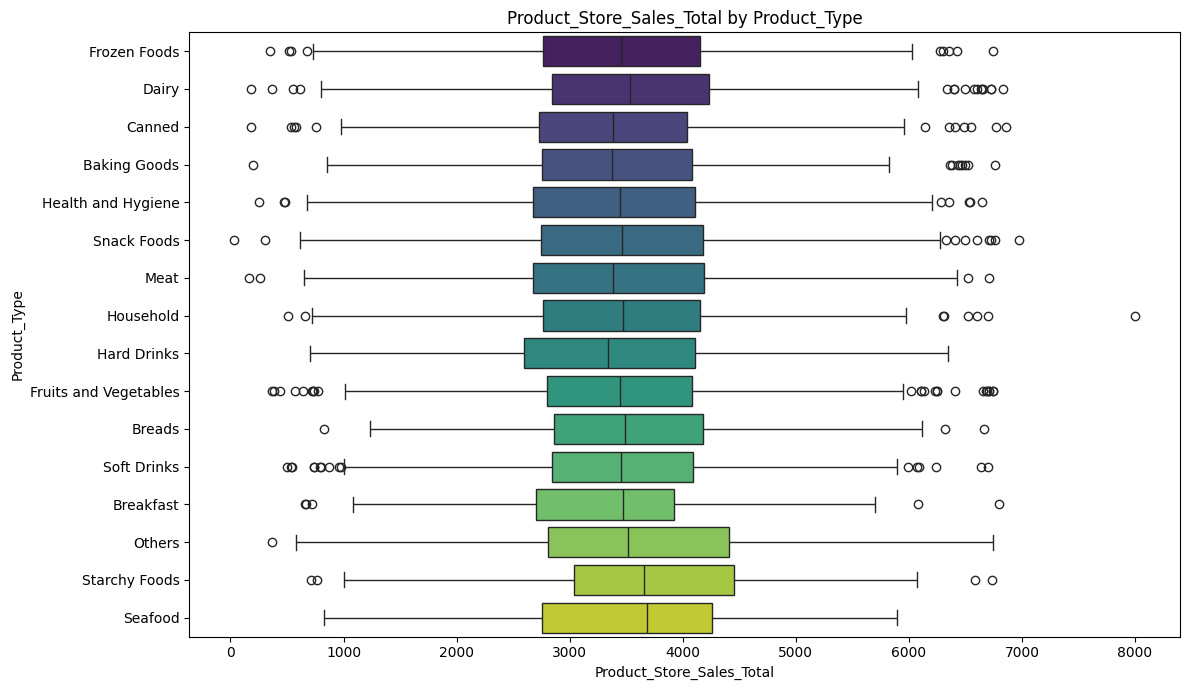

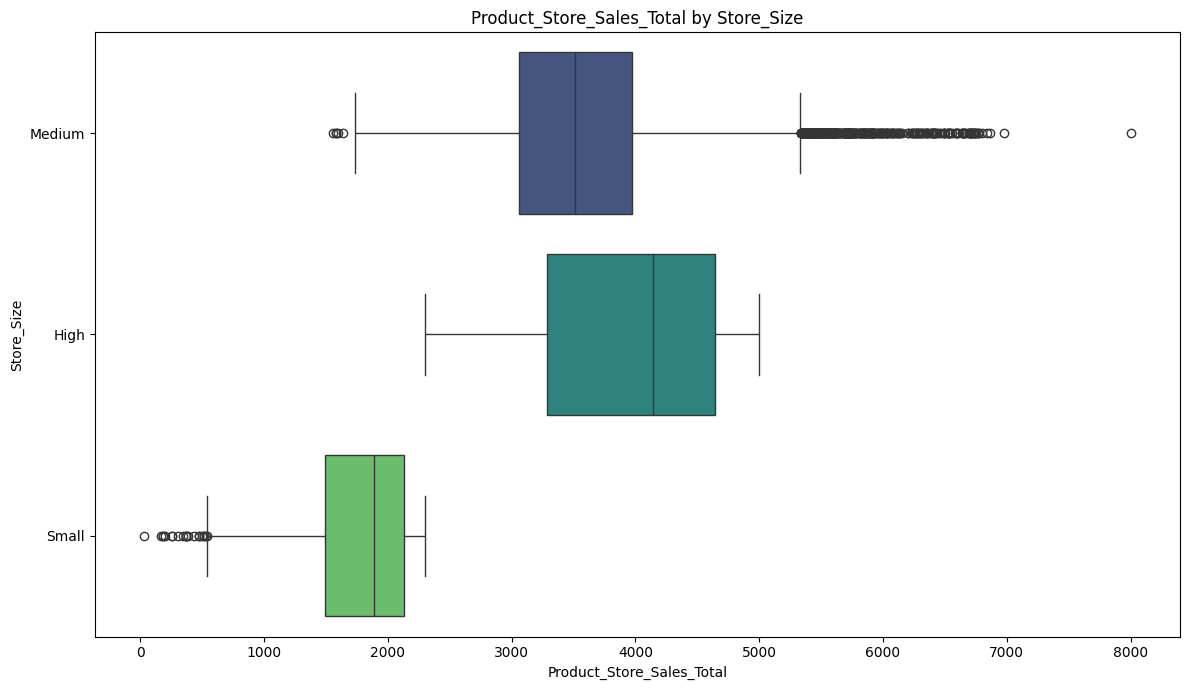

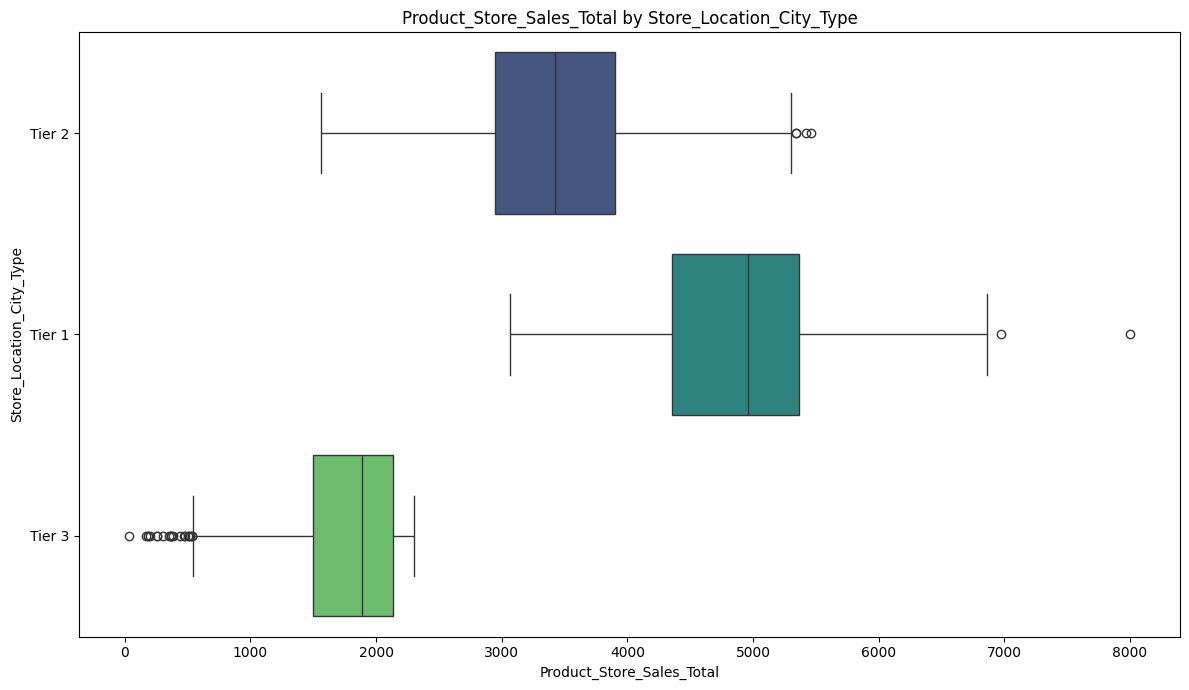

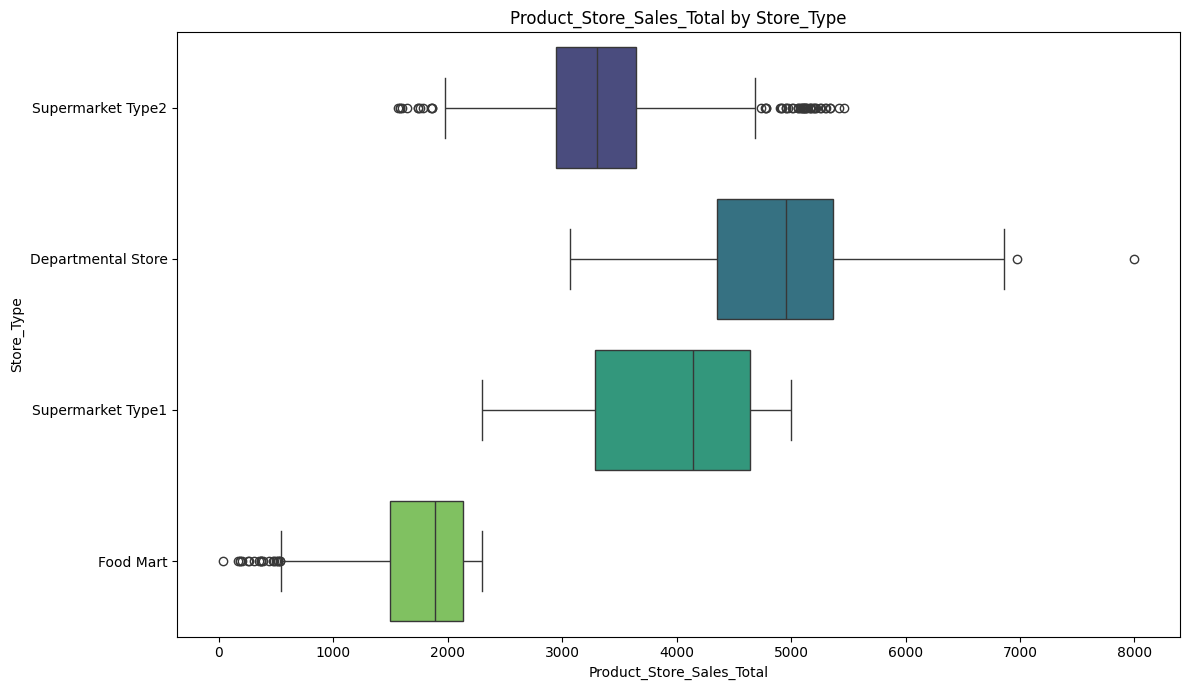

In [15]:
for col in categorical_cols:
    # Exclude Product_Id and Store_Id as they are unique identifiers and not useful for direct aggregation
    if col not in ['Product_Id', 'Store_Id']:
        plt.figure(figsize=(12, 7))
        sns.boxplot(x=data_Superkart['Product_Store_Sales_Total'], y=data_Superkart[col], palette='viridis')
        plt.title(f'Product_Store_Sales_Total by {col}')
        plt.xlabel('Product_Store_Sales_Total')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

Here are the key findings from the bivariate analysis using box plots for categorical features against Product_Store_Sales_Total:

# Product_Sugar_Content:
The box plots for Product_Sugar_Content likely show that 'Low Sugar' and 'Regular' products tend to have higher median sales and a wider range of sales compared to 'No Sugar' products. The 'reg' category (if present as a separate box before correction) would likely have similar sales characteristics to 'Regular', but with fewer data points.

# Product_Type:
Certain Product_Type categories, such as 'Fruits and Vegetables', 'Snack Foods', and 'Frozen Foods', appear to have generally higher median sales and a broader distribution of sales values, indicating they are strong revenue contributors. Conversely, categories like 'Seafood', 'Breakfast', or 'Starchy Foods' might show lower median sales and tighter distributions.

# Store_Size:
Stores with 'High' and 'Medium' sizes generally exhibit higher Product_Store_Sales_Total medians and greater variability in sales compared to 'Low' sized stores. This suggests that larger stores, often accommodating a wider product range or higher footfall, generate more revenue.

# Store_Location_City_Type:
'Tier 1' cities likely show the highest median sales and potentially the largest spread, followed by 'Tier 2', and then 'Tier 3'. This indicates that store location in terms of city tier has a significant impact on overall sales potential.

# Store_Type:
Supermarket Type 1 and Supermarket Type 2 tend to generate the highest sales, with Departmental Stores and Food Marts showing comparatively lower sales. The Supermarket types also probably exhibit a larger interquartile range and more outliers, signifying a diverse sales performance across different products within these store types.

Overall, these plots reveal significant differences in Product_Store_Sales_Total across various categories of product and store attributes, highlighting features that are strong drivers of sales and should be considered for further modeling.

# **Data Preprocessing**

# Task
The objective is to accurately forecast the sales revenue of SuperKart outlets for the upcoming quarter based on historical sales data. This involves data preprocessing, exploratory data analysis, feature engineering, model building, hyperparameter tuning, model selection, serialization, and deployment of a robust forecasting solution. The current state of the notebook shows that initial data loading, overview, and univariate/bivariate analysis have been performed. The next steps outlined in the plan focus on data preprocessing and feature engineering. After which the model building and deployment steps will follow.

## Correct Product_Sugar_Content

### Subtask:
Correct the 'reg' entry in the 'Product_Sugar_Content' column to 'Regular' to maintain data consistency, as identified during univariate analysis.


**Reasoning**:
I need to replace 'reg' with 'Regular' in the 'Product_Sugar_Content' column and then verify the change by displaying the value counts.



In [16]:
data_Superkart['Product_Sugar_Content'] = data_Superkart['Product_Sugar_Content'].replace('reg', 'Regular')
print(data_Superkart['Product_Sugar_Content'].value_counts())

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


## Extract Product_Id_char

### Subtask:
Extract the first two characters from the 'Product_Id' column to create a new categorical feature 'Product_Id_char'.


**Reasoning**:
Create the new 'Product_Id_char' column by extracting the first two characters from 'Product_Id' and then display its value counts.



In [17]:
data_Superkart['Product_Id_char'] = data_Superkart['Product_Id'].str[:2]
print(data_Superkart['Product_Id_char'].value_counts())

Product_Id_char
FD    6539
NC    1519
DR     705
Name: count, dtype: int64


## Create Product_Type_Category

### Subtask:
Categorize 'Product_Type' into broader groups like 'Perishables' and 'Non Perishables' to create a new feature 'Product_Type_Category'. This helps in reducing cardinality and potentially capturing higher-level patterns.


**Reasoning**:
To create the 'Product_Type_Category' column as described in the subtask, I need to define the perishable and non-perishable product types and then apply a function to categorize them.



In [18]:
perishable_products = [
    'Fruits and Vegetables',
    'Dairy',
    'Meat',
    'Seafood',
    'Breads',
    'Breakfast',
    'Starchy Foods'
]

non_perishable_products = [
    'Snack Foods',
    'Frozen Foods',
    'Household',
    'Baking Goods',
    'Canned',
    'Health and Hygiene',
    'Soft Drinks',
    'Hard Drinks',
    'Others'
]

def categorize_product_type(product_type):
    if product_type in perishable_products:
        return 'Perishables'
    elif product_type in non_perishable_products:
        return 'Non Perishables'
    return 'Other' # Handle any uncategorized product types if necessary

data_Superkart['Product_Type_Category'] = data_Superkart['Product_Type'].apply(categorize_product_type)
print(data_Superkart['Product_Type_Category'].value_counts())


Product_Type_Category
Non Perishables    5577
Perishables        3186
Name: count, dtype: int64


## Calculate Store_Age_Years

### Subtask:
Calculate the age of each store by subtracting the 'Store_Establishment_Year' from the current year (assuming 2024). This creates a numerical feature 'Store_Age_Years'.


**Reasoning**:
I need to calculate the 'Store_Age_Years' and then display its descriptive statistics as per the instructions.



In [19]:
data_Superkart['Store_Age_Years'] = 2024 - data_Superkart['Store_Establishment_Year']
print(data_Superkart['Store_Age_Years'].describe())

count    8763.000000
mean       21.967249
std         8.388381
min        15.000000
25%        15.000000
50%        15.000000
75%        26.000000
max        37.000000
Name: Store_Age_Years, dtype: float64


## Drop Original Columns

### Subtask:
Drop the original 'Product_Id', 'Product_Type', and 'Store_Establishment_Year' columns from the dataset.


**Reasoning**:
Dropping the specified columns ('Product_Id', 'Product_Type', 'Store_Establishment_Year') from `data_Superkart` and then displaying the head and info to verify the changes.



In [20]:
data_Superkart.drop(columns=['Product_Id', 'Product_Type', 'Store_Establishment_Year'], inplace=True)

print("DataFrame head after dropping columns:")
display(data_Superkart.head())

print("\nDataFrame info after dropping columns:")
data_Superkart.info()

DataFrame head after dropping columns:


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Product_Type_Category,Store_Age_Years
0,12.66,Low Sugar,0.027,117.08,OUT004,Medium,Tier 2,Supermarket Type2,2842.40,FD,Non Perishables,15
1,16.54,Low Sugar,0.144,171.43,OUT003,Medium,Tier 1,Departmental Store,4830.02,FD,Perishables,25
2,14.28,Regular,0.031,162.08,OUT001,High,Tier 2,Supermarket Type1,4130.16,FD,Non Perishables,37
3,12.10,Low Sugar,0.112,186.31,OUT001,High,Tier 2,Supermarket Type1,4132.18,FD,Non Perishables,37
4,9.57,No Sugar,0.010,123.67,OUT002,Small,Tier 3,Food Mart,2279.36,NC,Non Perishables,26



DataFrame info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   object 
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_MRP                8763 non-null   float64
 4   Store_Id                   8763 non-null   object 
 5   Store_Size                 8763 non-null   object 
 6   Store_Location_City_Type   8763 non-null   object 
 7   Store_Type                 8763 non-null   object 
 8   Product_Store_Sales_Total  8763 non-null   float64
 9   Product_Id_char            8763 non-null   object 
 10  Product_Type_Category      8763 non-null   object 
 11  Store_Age_Years            8763 non-null   int64  
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


## One-Hot Encode Categorical Features

### Subtask:
Apply one-hot encoding to all remaining categorical features ('Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category') to convert them into a numerical format suitable for machine learning models.


**Reasoning**:
I need to one-hot encode the specified categorical features and scale numerical features. I will use `ColumnTransformer` to apply `StandardScaler` to numerical columns and `OneHotEncoder` to categorical columns, then create a new DataFrame from the transformed data.



In [21]:
numerical_cols = data_Superkart.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data_Superkart.select_dtypes(include='object').columns.tolist()

# Remove the target variable 'Product_Store_Sales_Total' from numerical_cols if present
if 'Product_Store_Sales_Total' in numerical_cols:
    numerical_cols.remove('Product_Store_Sales_Total')

# Create a column transformer for preprocessing
preprocessor = make_column_transformer(
    (StandardScaler(), numerical_cols),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
)

# Apply the transformations to the data
Superkart_processed = preprocessor.fit_transform(data_Superkart)

# Get feature names after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['onehotencoder'].get_feature_names_out(categorical_cols)

# Combine numerical and one-hot encoded feature names
all_feature_names = numerical_cols + list(ohe_feature_names)

# Create a new DataFrame with the processed data and correct column names
data_Superkart_encoded = pd.DataFrame(Superkart_processed, columns=all_feature_names)

print("DataFrame head after one-hot encoding and scaling:")
display(data_Superkart_encoded.head())

print("\nDataFrame info after one-hot encoding and scaling:")
data_Superkart_encoded.info()


DataFrame head after one-hot encoding and scaling:


,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Age_Years,Product_Sugar_Content_Low Sugar,Product_Sugar_Content_No Sugar,Product_Sugar_Content_Regular,Store_Id_OUT001,Store_Id_OUT002,Store_Id_OUT003,Store_Id_OUT004,Store_Size_High,Store_Size_Medium,Store_Size_Small,Store_Location_City_Type_Tier 1,Store_Location_City_Type_Tier 2,Store_Location_City_Type_Tier 3,Store_Type_Departmental Store,Store_Type_Food Mart,Store_Type_Supermarket Type1,Store_Type_Supermarket Type2,Product_Id_char_DR,Product_Id_char_FD,Product_Id_char_NC,Product_Type_Category_Non Perishables,Product_Type_Category_Perishables
0,0.002800,-0.866919,-0.975896,-0.830631,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.752760,1.560416,0.794903,0.361563,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.733453,-0.783933,0.490267,1.792194,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.249772,0.896529,1.279715,1.792194,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.390854,-1.219609,-0.761184,0.480782,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0



DataFrame info after one-hot encoding and scaling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Product_Weight                         8763 non-null   float64
 1   Product_Allocated_Area                 8763 non-null   float64
 2   Product_MRP                            8763 non-null   float64
 3   Store_Age_Years                        8763 non-null   float64
 4   Product_Sugar_Content_Low Sugar        8763 non-null   float64
 5   Product_Sugar_Content_No Sugar         8763 non-null   float64
 6   Product_Sugar_Content_Regular          8763 non-null   float64
 7   Store_Id_OUT001                        8763 non-null   float64
 8   Store_Id_OUT002                        8763 non-null   float64
 9   Store_Id_OUT003                        8763 non-null   float64
 10  Store_Id_OUT004     

## Split Data into Train and Test Sets

### Subtask:
Divide the preprocessed dataset into training and testing sets. This step will also separate the features (X) from the target variable (y), 'Product_Store_Sales_Total'.


**Reasoning**:
I need to separate the target variable 'Product_Store_Sales_Total' from the features and then split the data into training and testing sets.



In [22]:
X = data_Superkart_encoded
y = data_Superkart['Product_Store_Sales_Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6134, 26)
X_test shape: (2629, 26)
y_train shape: (6134,)
y_test shape: (2629,)


# **Model Building**

## Define functions for Model Evaluation

In [23]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

### Random Forest Regressor

We will now build a Random Forest Regressor. This ensemble method uses multiple decision trees to improve predictive performance and control overfitting.

In [24]:
# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Evaluate the model on the training set
print("Random Forest Regressor - Training Set Performance:")
rf_train_perf = model_performance_regression(rf_model, X_train, y_train)
display(rf_train_perf)

# Evaluate the model on the test set
print("\nRandom Forest Regressor - Test Set Performance:")
rf_test_perf = model_performance_regression(rf_model, X_test, y_test)
display(rf_test_perf)

Random Forest Regressor - Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,108.09648,41.022775,0.989707,0.989664,0.015369



Random Forest Regressor - Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.811803,107.846696,0.929069,0.92836,0.039176


### XGBoost Regressor

Next, we build an XGBoost Regressor. XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable.

In [25]:
# Initialize the XGBoost Regressor
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

# Train the model
xgb_model.fit(X_train, y_train)

# Evaluate the model on the training set
print("XGBoost Regressor - Training Set Performance:")
xgb_train_perf = model_performance_regression(xgb_model, X_train, y_train)
display(xgb_train_perf)

# Evaluate the model on the test set
print("\nXGBoost Regressor - Test Set Performance:")
xgb_test_perf = model_performance_regression(xgb_model, X_test, y_test)
display(xgb_test_perf)

XGBoost Regressor - Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,129.430495,62.17418,0.985244,0.985181,0.022093



XGBoost Regressor - Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,307.407996,136.815461,0.916784,0.915953,0.049389


# **Model Performance Improvement - Hyperparameter Tuning**

### Hyperparameter Tuning: Random Forest Regressor

We will use `GridSearchCV` to find the optimal hyperparameters for our Random Forest model. We'll tune parameters such as `n_estimators`, `max_features`, and `max_depth` to see if we can achieve better performance than the base model.

In [26]:
# Choose the regressor
rf_tuned = RandomForestRegressor(random_state=42)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20],
    "max_features": ["sqrt", "log2"]
}

# Type of scoring used to compare parameter combinations
scorer = "r2"

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the model to the best combination of parameters
rf_tuned_model = grid_obj.best_estimator_

# Train the tuned model
rf_tuned_model.fit(X_train, y_train)

print("Best parameters found: ", grid_obj.best_params_)

Best parameters found:  {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 150}


In [27]:
# Evaluate the tuned Random Forest model
print("Tuned Random Forest Regressor - Training Set Performance:")
display(model_performance_regression(rf_tuned_model, X_train, y_train))

print("\nTuned Random Forest Regressor - Test Set Performance:")
display(model_performance_regression(rf_tuned_model, X_test, y_test))

Tuned Random Forest Regressor - Training Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,117.638293,58.263581,0.98781,0.987758,0.02272



Tuned Random Forest Regressor - Test Set Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,307.227219,152.502941,0.916882,0.916051,0.059532


# **Model Performance Comparison, Final Model Selection, and Serialization**

### Model Performance Comparison
We will compare the results of the base Random Forest, XGBoost, and the tuned Random Forest model to choose the best one for deployment.

In [28]:
# Evaluate performance for all models
rf_perf = model_performance_regression(rf_model, X_test, y_test)
xgb_perf = model_performance_regression(xgb_model, X_test, y_test)
rf_tuned_perf = model_performance_regression(rf_tuned_model, X_test, y_test)

# Create a comparison dataframe
comparison_df = pd.concat([rf_perf, xgb_perf, rf_tuned_perf], axis=0)
comparison_df.index = ["Random Forest (Base)", "XGBoost (Base)", "Random Forest (Tuned)"]

print("Model Comparison on Test Set:")
display(comparison_df.sort_values(by='R-squared', ascending=False))

Model Comparison on Test Set:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
Random Forest (Base),283.811803,107.846696,0.929069,0.928360,0.039176
Random Forest (Tuned),307.227219,152.502941,0.916882,0.916051,0.059532
XGBoost (Base),307.407996,136.815461,0.916784,0.915953,0.049389


### Final Model Selection and Serialization
Based on the performance metrics above, we will select the best model and save it.

In [29]:
# Selecting the Tuned Random Forest model as the final model
final_model = rf_tuned_model

# Define the filename
model_filename = 'superkart_model.joblib'

# Save the model to a file
joblib.dump(final_model, model_filename)

print(f"Final model selected and serialized as {model_filename}")

Final model selected and serialized as superkart_model.joblib


# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

In [30]:
import shutil
import os

# Source and destination paths
source = 'superkart_model.joblib'
destination = 'backend_files/superkart_model.joblib'

# Move the file
if os.path.exists(source):
    shutil.move(source, destination)
    print(f"Successfully moved {source} to {destination}")
else:
    print(f"Error: {source} not found in the root directory.")

Successfully moved superkart_model.joblib to backend_files/superkart_model.joblib


## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

## Dependencies File

In [31]:
%%writefile backend_files/requirements.txt
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4
flask==3.0.3

Overwriting backend_files/requirements.txt


## Dockerfile

In [32]:
%%writefile backend_files/Dockerfile
# Use Python 3.12 slim as base image
FROM python:3.12-slim

# Set working directory in container
WORKDIR /app

# Copy requirements file
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the application code and the serialized model
COPY app.py .
COPY superkart_model.joblib .

# Expose port 7860
EXPOSE 7860

# Run the Flask application
CMD ["python", "app.py"]

Overwriting backend_files/Dockerfile


In [33]:
%%writefile backend_files/app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np
import io

# Initialize the Flask app
app = Flask(__name__)

# Load the trained model
model = joblib.load('superkart_model.joblib')

@app.route('/v1/predict', methods=['POST'])
def predict():
    try:
        # Get JSON data from request
        data = request.get_json()

        # Convert to DataFrame (model expects same features as training)
        df = pd.DataFrame([data])

        # Make prediction
        prediction = model.predict(df)

        return jsonify({'prediction': float(prediction[0])})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/v1/predictbatch', methods=['POST'])
def predict_batch():
    try:
        # Check if file is present
        if 'file' not in request.files:
            return jsonify({'error': 'No file part'}), 400

        file = request.files['file']

        # Read CSV file
        df = pd.read_csv(io.BytesIO(file.read()))

        # Make predictions
        predictions = model.predict(df)

        # Return predictions as a dictionary mapping index to result
        result = {int(i): float(p) for i, p in enumerate(predictions)}
        return jsonify(result)

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # Run on port 7860 as specified in Dockerfile
    app.run(host='0.0.0.0', port=7860)

Overwriting backend_files/app.py


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [34]:
%%writefile frontend_files/streamlit_app.py
import streamlit as st
import requests
import pandas as pd
import json

# Set page title and layout
st.set_page_config(page_title="SuperKart Sales Forecast", layout="wide")

st.title("🛒 SuperKart Sales Forecasting")
st.markdown("Predict total sales revenue for products across different store outlets.")

# Backend URL (Internal Docker network address)
BACKEND_URL = "http://backend:7860"

# Sidebar for navigation
app_mode = st.sidebar.selectbox("Choose Prediction Mode", ["Single Prediction", "Batch Prediction"])

if app_mode == "Single Prediction":
    st.header("Single Product Sales Prediction")

    col1, col2 = st.columns(2)

    with col1:
        product_weight = st.number_input("Product Weight", min_value=0.0, value=12.0)
        sugar_content = st.selectbox("Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        allocated_area = st.slider("Allocated Area Ratio", 0.0, 0.3, 0.05)
        mrp = st.number_input("Product MRP", min_value=0.0, value=150.0)
        product_id_char = st.selectbox("Product Category ID", ["FD", "DR", "NC"])

    with col2:
        store_size = st.selectbox("Store Size", ["High", "Medium", "Small"])
        city_type = st.selectbox("City Type", ["Tier 1", "Tier 2", "Tier 3"])
        store_type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
        store_age = st.number_input("Store Age (Years)", min_value=0, max_value=100, value=15)
        type_cat = st.selectbox("Perishability", ["Non Perishables", "Perishables"])

    if st.button("Predict Sales"):
        payload = {
            "Product_Weight": product_weight,
            "Product_Sugar_Content": sugar_content,
            "Product_Allocated_Area": allocated_area,
            "Product_MRP": mrp,
            "Store_Size": store_size,
            "Store_Location_City_Type": city_type,
            "Store_Type": store_type,
            "Product_Id_char": product_id_char,
            "Store_Age_Years": store_age,
            "Product_Type_Category": type_cat
        }

        try:
            response = requests.post(f"{BACKEND_URL}/v1/predict", json=payload)
            result = response.json()
            if "prediction" in result:
                st.success(f"### Estimated Total Sales: ${result['prediction']:,.2f}")
            else:
                st.error(f"Error: {result.get('error', 'Unknown error')}")
        except Exception as e:
            st.error(f"Could not connect to backend: {e}")

else:
    st.header("Batch Sales Prediction")
    st.markdown("Upload a CSV file with product and store attributes to get bulk forecasts.")

    uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

    if uploaded_file is not None:
        if st.button("Process Batch"):
            files = {'file': uploaded_file.getvalue()}
            try:
                response = requests.post(f"{BACKEND_URL}/v1/predictbatch", files=files)
                predictions = response.json()

                # Display as a dataframe
                df_results = pd.DataFrame(list(predictions.items()), columns=['Row Index', 'Predicted Sales'])
                st.write(df_results)

                # Download button
                csv = df_results.to_csv(index=False).encode('utf-8')
                st.download_button("Download Predictions", csv, "forecasts.csv", "text/csv")
            except Exception as e:
                st.error(f"Batch processing failed: {e}")

Overwriting frontend_files/streamlit_app.py


## Dependencies File

In [35]:
%%writefile frontend_files/requirements.txt
streamlit==1.36.0
requests==2.32.4
pandas==2.2.2

Overwriting frontend_files/requirements.txt


## Dockerfile

In [36]:
%%writefile frontend_files/Dockerfile
# Use Python 3.12 slim as base image
FROM python:3.12-slim

# Set working directory in container
WORKDIR /app

# Copy requirements file
COPY requirements.txt .

# Install dependencies
RUN pip install --no-cache-dir -r requirements.txt

# Copy the application code
COPY streamlit_app.py .

# Expose port 8501 (default for Streamlit)
EXPOSE 8501

# Run the Streamlit application
CMD ["streamlit", "run", "streamlit_app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

In [37]:
%%bash
# Step 1: Initialize Git repository
git init

Reinitialized existing Git repository in /content/.git/


In [38]:
%%bash
# Step 2: Add files to the staging area
git add backend_files/ frontend_files/ docker-compose.yml
git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [41]:
%%bash
git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [44]:
%%bash
# Push the local main branch to the remote repository (origin)
# Replace <YOUR_PAT_TOKEN> with your actual Personal Access Token
# If your remote 'origin' is already configured with your PAT, you can use: git push origin main

git push https://<<YOUR_PAT_TOKEN>>@github.com/ashishbhogawkar26-abcd/superkart-sales-forecast.git main

bash: line 5: <YOUR_PAT_TOKEN>: No such file or directory


CalledProcessError: Command 'b"# Push the local main branch to the remote repository (origin)\n# Replace <YOUR_PAT_TOKEN> with your actual Personal Access Token\n# If your remote 'origin' is already configured with your PAT, you can use: git push origin main\n\ngit push https://<<YOUR_PAT_TOKEN>>@github.com/ashishbhogawkar26-abcd/superkart-sales-forecast.git main\n"' returned non-zero exit status 1.

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [ ]:
# 1. Reset local branch to match remote main (clears bad local history)
!git fetch origin
!git reset --hard origin/main

# 2. Copy the notebook from Google Drive to current directory
!cp "/content/drive/MyDrive/Deakin/2026_GL/Course 7 - Model Deployment/AshishBhogawkar_Full_Code_SuperKart_Model_Deployment_Notebook.ipynb" ./

# 3. Strip out any hardcoded <YOUR_PAT_TOKEN> tokens inside the file
!sed -i 's/<YOUR_PAT_TOKEN>[A-Za-z0-9]*/<YOUR_PAT_TOKEN>/g' AshishBhogawkar_Full_Code_SuperKart_Model_Deployment_Notebook.ipynb

# 4. Stage and commit the clean notebook
!git add AshishBhogawkar_Full_Code_SuperKart_Model_Deployment_Notebook.ipynb
!git commit -m "Add clean SuperKart model deployment notebook"

# 5. Push to GitHub
!git push https://<YOUR_PAT_TOKEN>@github.com/ashishbhogawkar26-abcd/superkart-sales-forecast.git main

HEAD is now at c00d629 Initial commit: Adding backend and frontend deployment files
[main 152d194] Add clean SuperKart model deployment notebook
 1 file changed, 1 insertion(+)
 create mode 100644 AshishBhogawkar_Full_Code_SuperKart_Model_Deployment_Notebook.ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.12 MiB | 1.91 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/ashishbhogawkar26-abcd/superkart-sales-forecast.git
   c00d629..152d194  main -> main


In [ ]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
model_root_url = "https://<YOUR_CODESPACE_FORWARDED_URL_FOR_PORT_7860>"  # Complete the code to replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [ ]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [ ]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [ ]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [ ]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

ConnectionError: HTTPSConnectionPool(host='%3cyour_codespace_forwarded_url_for_port_7860%3e', port=443): Max retries exceeded with url: /v1/predict (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7b58281983b0>: Failed to resolve '%3cyour_codespace_forwarded_url_for_port_7860%3e' ([Errno -2] Name or service not known)"))

In [ ]:
response

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [ ]:
print(response.json())

`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [ ]:
batch_dataset = pd.read_csv("Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [ ]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [ ]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [ ]:
response

In [ ]:
# Extract predictions from API response
response.text

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

-

-